In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
iris = sns.load_dataset('iris')

In [5]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
from sklearn.datasets import load_iris

In [9]:
x = iris.iloc[:,:-1]
y = load_iris().target

In [22]:
dtree = DecisionTreeClassifier(max_depth=2)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=20,random_state=42)

In [25]:
dtree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [26]:
from sklearn import tree

[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.666\nsamples = 130\nvalue = [44, 41, 45]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 44\nvalue = [44, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= 1.75\ngini = 0.499\nsamples = 86\nvalue = [0, 41, 45]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.198\nsamples = 45\nvalue = [0, 40, 5]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.048\nsamples = 41\nvalue = [0, 1, 40]')]

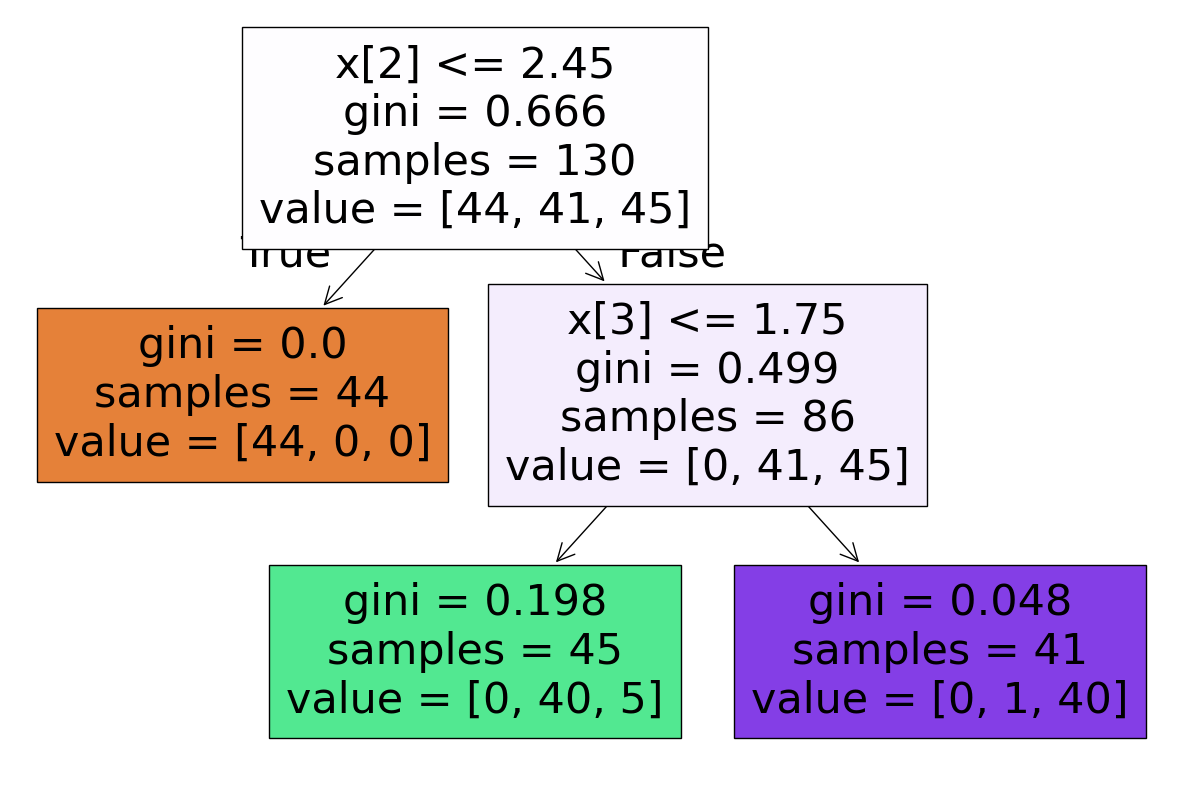

In [27]:
plt.figure(figsize=(15,10))
tree.plot_tree(dtree, filled= True)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [32]:
test_pred = dtree.predict(x_test)
train_pred = dtree.predict(x_train)

In [33]:
accuracy_score(y_test,test_pred)

1.0

In [34]:
accuracy_score(y_train,train_pred)

0.9538461538461539

In [35]:
confusion_matrix(y_test,test_pred)

array([[6, 0, 0],
       [0, 9, 0],
       [0, 0, 5]])

# Post Pruning

In [1]:
import numpy as pn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
from sklearn.datasets import load_iris

In [3]:
x,y = load_iris(return_X_y=True)

In [7]:
dataset = sns.load_dataset('iris')

In [8]:
dataset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
dataset = dataset[dataset['species']!='setosa']

In [12]:
dataset.species.unique()

array(['versicolor', 'virginica'], dtype=object)

In [16]:
dataset['species'] = dataset.species.map({"versicolor":0,"virginica":1})

C:\Users\memon\AppData\Local\Temp\ipykernel_7660\184444167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['species'] = dataset.species.map({"versicolor":0,"virginica":1})


In [19]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [22]:
x_train,x_test ,y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42)

In [62]:
Tree_classifier = DecisionTreeClassifier(max_depth=3)

In [63]:
Tree_classifier.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [64]:
train_pred = Tree_classifier.predict(x_train)
test_pred = Tree_classifier.predict(x_test)

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [66]:
print("Training Accuracy:",accuracy_score(y_train,train_pred))
print("Testing Accuracy:",accuracy_score(y_test, test_pred))

Training Accuracy: 1.0
Testing Accuracy: 0.96


In [50]:
import sklearn.tree as tree

[Text(0.5, 0.75, 'x[2] <= 4.95\ngini = 0.499\nsamples = 75\nvalue = [36, 39]'),
 Text(0.25, 0.25, 'gini = 0.102\nsamples = 37\nvalue = [35, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.051\nsamples = 38\nvalue = [1, 37]'),
 Text(0.625, 0.5, '  False')]

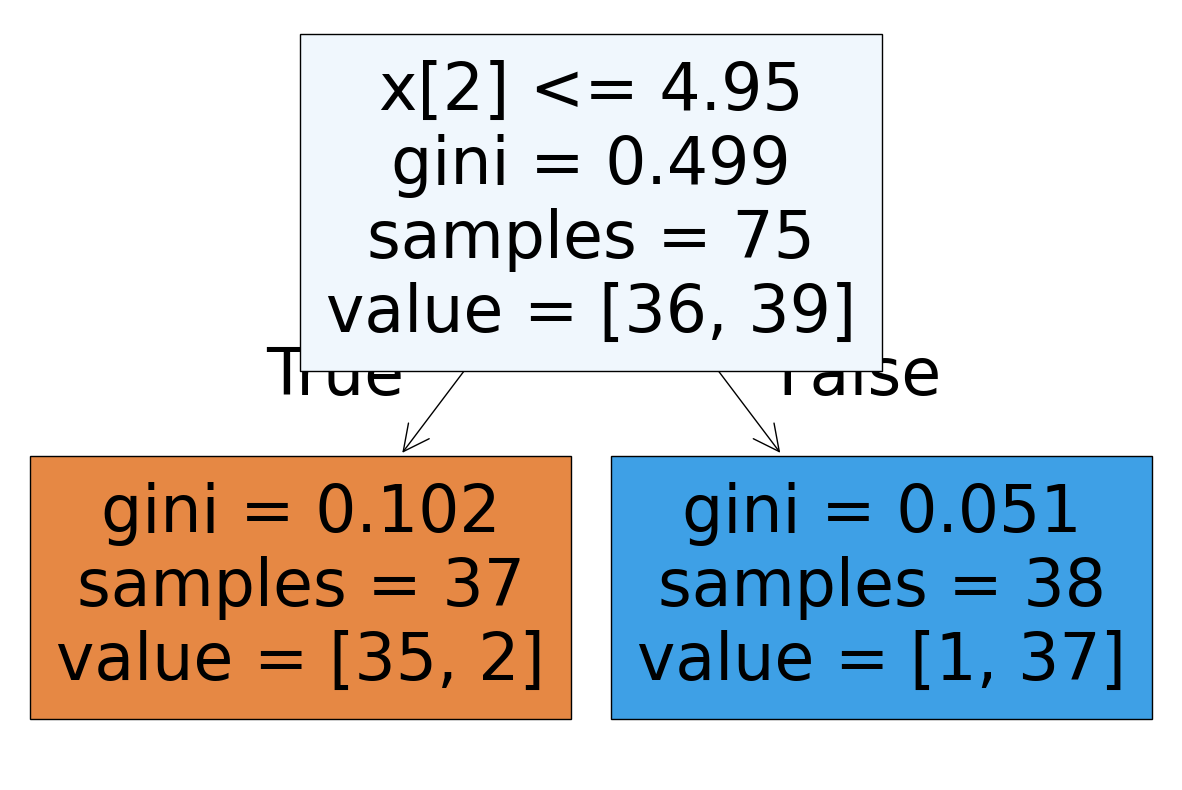

In [51]:
plt.figure(figsize=(15,10))
tree.plot_tree(Tree_classifier, filled=True)

# Pre Pruning

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
para = {"max_depth":[1,2,3,4,5,6,7,8]}

In [74]:
tc = DecisionTreeClassifier()
grid = GridSearchCV(tc,param_grid=para, cv = 5, scoring='accuracy')

In [75]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8]},
             scoring='accuracy')

In [76]:
grid.best_score_

np.float64(0.9466666666666667)

In [73]:
grid.predict(x_test)

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1])